## 1. Setup and imports


In [1]:
# Notebook designed to run from a subdirectory
%matplotlib inline
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

import aif360.algorithms.preprocessing
from aif360.datasets import BinaryLabelDataset, StructuredDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.algorithms.inprocessing.adversarial_debiasing import AdversarialDebiasing
from aif360.metrics.utils import compute_boolean_conditioning_vector
from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing


# for definition of original models
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
# from sklearn.svm import SVC
# from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


import tensorflow as tf
from IPython.display import Markdown, display
import warnings

2026-09-29 22:46:58.856618: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-29 22:46:59.104192: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-29 22:47:03.961067: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/len_lin/Documents/ADNI/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
pip install 'aif360[inFairness]'


## 2. Fairness metrics


In [2]:
# Wraps aif360 ClassificationMetric into a clean OrderedDict
from collections import OrderedDict
from aif360.metrics import ClassificationMetric

def compute_metrics(dataset_true, dataset_pred, 
                    unprivileged_groups, privileged_groups,
                    disp = True):
    """ Compute the key metrics """
    classified_metric_pred = ClassificationMetric(dataset_true,
                                                 dataset_pred, 
                                                 unprivileged_groups=unprivileged_groups,
                                                 privileged_groups=privileged_groups)
    metrics = OrderedDict()
    metrics["Balanced accuracy"] = 0.5*(classified_metric_pred.true_positive_rate()+
                                             classified_metric_pred.true_negative_rate())
    
    metrics["Average odds difference"] = classified_metric_pred.average_odds_difference()
    metrics["Disparate impact"] = classified_metric_pred.disparate_impact()
    metrics["Equal opportunity difference"] = classified_metric_pred.equal_opportunity_difference()
    metrics["Mean Difference"] = classified_metric_pred.mean_difference()
    metrics["Statistical parity difference"] = classified_metric_pred.statistical_parity_difference()
    metrics["Theil index"] = classified_metric_pred.theil_index()
    
    if disp:
        for k in metrics:
            print("%s = %.4f" % (k, metrics[k]))
    
    return metrics

## 3. Data preparation


In [3]:
# 757 subjects x 147 columns; Sex: 0=male, 1=female; DIAGNOSIS: 0=MCI, 1=AD
df = pd.read_csv('data_4mod_MCIvsAD.csv')
print(df.shape)
df.head()

(757, 147)


,PTID,DIAGNOSIS,Sex,age,DXNODEP,DXMCI,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,...,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS,ICV
0,002_S_1155,0,0,57.9,0,0,1,1,1,1,...,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0,1536260.810
1,002_S_4229,0,0,66.4,0,0,1,0,1,1,...,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0,1447939.000
2,002_S_4473,0,0,74.8,0,0,1,1,1,1,...,13.0,0.053020,8.0,0.026710,20.0,0.077603,21.0,0.137151,21.0,1678392.749
3,002_S_4654,0,1,75.5,0,0,1,1,1,1,...,11.0,0.045150,8.0,0.027749,19.0,0.067913,19.0,0.119390,19.0,1548503.921
4,002_S_4799,0,0,81.3,0,0,1,0,1,1,...,13.0,0.043899,7.0,0.025049,18.0,0.086488,19.0,0.133770,19.0,1560673.616


In [4]:
# Check joint distribution of diagnosis and sex
print(df.value_counts(subset=['DIAGNOSIS', 'Sex'], sort=False))

DIAGNOSIS  Sex
0          0      331
           1      269
1          0       89
           1       68
Name: count, dtype: int64


In [5]:
print(df['Sex'].value_counts())
df['Sex'].value_counts(normalize=True)
print(df['DIAGNOSIS'].value_counts())

Sex
0    420
1    337
Name: count, dtype: int64
DIAGNOSIS
0    600
1    157
Name: count, dtype: int64


In [6]:
# Save PTIDs for later identification
df_PTID=df[['PTID']]
# print(df_PTID.shape)
# df_PTID.head()

In [7]:
# Drop metadata, diagnosis flags, and DXMPTR* proxy columns (18 total)
df = df.drop(['PTID','CDRSB', 'PTHAND', 'PTCOGBEG', 'DXDSEV','DXMDUE', 'DXMCI', 'DXAD', 'DXAPP', 'DXDDUE', 'PTADDX', 'ICV'], axis=1) 
df = df.drop(['DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6'], axis=1)
print(df.shape)
df.head()

(757, 129)


,DIAGNOSIS,Sex,age,DXNODEP,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,...,RIGHT_BA36_VOL,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS
0,0,0,57.9,0,0,0,0,0,0,0,...,0.099781,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0
1,0,0,66.4,0,0,0,0,0,0,0,...,0.122244,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0
2,0,0,74.8,0,0,0,0,0,0,0,...,0.093440,13.0,0.053020,8.0,0.026710,20.0,0.077603,21.0,0.137151,21.0
3,0,1,75.5,0,0,0,0,0,0,0,...,0.059399,11.0,0.045150,8.0,0.027749,19.0,0.067913,19.0,0.119390,19.0
4,0,0,81.3,0,0,0,0,0,0,0,...,0.127571,13.0,0.043899,7.0,0.025049,18.0,0.086488,19.0,0.133770,19.0


In [8]:
# Sex=0 (male)=privileged, Sex=1 (female)=unprivileged; favorable label = AD (1)
# Binarize Training data
label_name = ['DIAGNOSIS']
protected_attribute_names = ['Sex']
    
dataset_Binary = BinaryLabelDataset(
    df=df,
    label_names=label_name,
    protected_attribute_names=protected_attribute_names,
    favorable_label=1,
    unfavorable_label=0)

unique_labels = dataset_Binary.labels.ravel() 

if len(np.unique(unique_labels)) != 2:
    raise ValueError("Dataset does not contain binary labels")
    
for attr in protected_attribute_names:
    unique_attrs = dataset_Binary.protected_attributes[:, dataset_Binary.protected_attribute_names.index(attr)]
    if len(np.unique(unique_attrs)) != 2:
        raise ValueError(f"Protected attribute '{attr}' is not binary")

In [9]:
# Get the dataset and split into train and test
# 66/34 split -> ~499 train / ~258 validation
dataset_orig_train, dataset_orig_valid = dataset_Binary.split([0.66])

privileged_groups = [{'Sex': 0}]
unprivileged_groups = [{'Sex': 1}]

In [10]:
metric_orig_train = BinaryLabelDatasetMetric(dataset_orig_train, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

display(Markdown("#### Original training dataset"))
print("disparate impact = %f" % metric_orig_train.disparate_impact())
print("Statistical parity difference = %f" % metric_orig_train.statistical_parity_difference())

#### Original training dataset

disparate impact = 0.823206
Statistical parity difference = -0.036119


In [11]:
metric_orig_valid = BinaryLabelDatasetMetric(dataset_orig_valid, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

display(Markdown("#### Original validation dataset"))
print("disparate impact = %f" % metric_orig_valid.disparate_impact())
print("Statistical parity difference = %f" % metric_orig_valid.statistical_parity_difference())

#### Original validation dataset

disparate impact = 1.167468
Statistical parity difference = 0.038007


In [12]:
X_train = dataset_orig_train.features
y_train = dataset_orig_train.labels.ravel()

# OS ratio in the training sample
# -------------------------------------
# uniqueytrain, countsytrain = np.unique(y_train, return_counts=True)
# display(Markdown("#### no of patients / controls in the Training dataset"))
# print(countsytrain)

In [13]:
# SMOTE resampling to balance MCI/AD (random_state=2 matches original analysis)
smote = SMOTE(random_state=2)
X_train_sampled, y_train_sampled = smote.fit_resample(X_train, y_train)

scale_orig = StandardScaler()
X_train = scale_orig.fit_transform(X_train_sampled)
y_train = y_train_sampled
X_valid = scale_orig.transform(dataset_orig_valid.features)


In [14]:
display(Markdown("#### Training Dataset shape after resampling"))
print(X_train.shape)

uniqueytrain, countsytrain = np.unique(y_train, return_counts=True)
display(Markdown("#### no of MCI / AD"))
print(countsytrain)

#### Training Dataset shape after resampling

(810, 128)


#### no of MCI / AD

[405 405]


## 4. Original model: training


SVC with poly kernel (C=0.1, gamma=0.1). Parameters were explored via GridSearchCV (C, kernel, gamma combinations); the chosen values are hardcoded for reproducibility.


In [15]:
# # SVC with poly kernel; params pre-selected via GridSearch
# model = SVC(C=0.1, gamma=0.1, kernel='poly', random_state=42, probability=True)


model=LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
                                   class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

/home/len_lin/Documents/ADNI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [16]:
# Predict training labels into aif360 dataset format
y_train_pred = model.predict(X_train)

pos_ind = np.where(model.classes_ == dataset_orig_train.favorable_label)[0][0]
dataset_orig_train_pred = dataset_orig_train.copy()
dataset_orig_train_pred.labels = y_train_pred

In [17]:
# Get probability scores on validation set for threshold tuning
## validation set
dataset_orig_valid_pred = dataset_orig_valid.copy(deepcopy=True)
X_test = scale_orig.transform(dataset_orig_valid_pred.features)
y_test = dataset_orig_valid_pred.labels
dataset_orig_valid_pred.scores = model.predict_proba(X_test)[:,pos_ind]

## 5. Original model: evaluation and threshold tuning


In [18]:
# Scan 100 thresholds (0.01-0.99) to maximize balanced accuracy
# Predictions from the original test set at the optimal classification threshold
# Find the optimal classification threshold from the test set
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

num_thresh = 100
ba_arr = np.zeros(num_thresh)
class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
for idx, class_thresh in enumerate(class_thresh_arr):
    
    fav_inds = dataset_orig_valid_pred.scores > class_thresh
    dataset_orig_valid_pred.labels[fav_inds] = dataset_orig_valid_pred.favorable_label
    dataset_orig_valid_pred.labels[~fav_inds] = dataset_orig_valid_pred.unfavorable_label
    
    classified_metric_valid = ClassificationMetric(dataset_orig_valid,
                                             dataset_orig_valid_pred, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
    
    ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
                       +classified_metric_valid.true_negative_rate())

best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
best_class_thresh = class_thresh_arr[best_ind]
dataset_orig_valid_pred.unfavorable_label

display(Markdown("#### Predictions from original testing data"))
bal_acc_arr_orig = []
avg_odds_diff_arr_orig = []
disp_imp_arr_orig = []
equal_opp_diff_arr_orig = [] #equal_opportunity_difference
mean_diff_arr_orig = []
stat_par_arr_orig = []
theil_ind_arr_orig = []


print("Classification threshold used = %.4f" % best_class_thresh)
for thresh in tqdm(class_thresh_arr):
    
    if thresh == best_class_thresh:
        disp = True
    else:
        disp = False
    
    fav_inds = dataset_orig_valid_pred.scores > thresh
    dataset_orig_valid_pred.labels[fav_inds] = dataset_orig_valid_pred.favorable_label
    dataset_orig_valid_pred.labels[~fav_inds] = dataset_orig_valid_pred.unfavorable_label
    
    metric_valid_bef = compute_metrics(dataset_orig_valid, dataset_orig_valid_pred, 
                                      unprivileged_groups, privileged_groups,
                                      disp = disp)

    bal_acc_arr_orig.append(metric_valid_bef["Balanced accuracy"])
    avg_odds_diff_arr_orig.append(metric_valid_bef["Average odds difference"])
    disp_imp_arr_orig.append(metric_valid_bef["Disparate impact"])
    equal_opp_diff_arr_orig.append(metric_valid_bef["Equal opportunity difference"])
    mean_diff_arr_orig.append(metric_valid_bef["Mean Difference"])
    stat_par_arr_orig.append(metric_valid_bef["Statistical parity difference"])
    theil_ind_arr_orig.append(metric_valid_bef["Theil index"])

#### Predictions from original testing data

Classification threshold used = 0.0100


 25%|██▌       | 25/100 [00:00<00:00, 242.31it/s]

Balanced accuracy = 0.8516
Average odds difference = -0.0413
Disparate impact = 0.9487
Equal opportunity difference = -0.0363
Mean Difference = -0.0171
Statistical parity difference = -0.0171
Theil index = 0.0708


100%|██████████| 100/100 [00:00<00:00, 238.87it/s]


## 6. Debiasing with Disparate Impact Remover


In [19]:
# DisparateImpactRemover pre-processing (repair_level=1 = full repair)
DIR = aif360.algorithms.preprocessing.DisparateImpactRemover(
       repair_level=1,  
       sensitive_attribute='Sex')

dataset_transf_train = DIR.fit_transform(dataset_orig_train)  

In [20]:
metric_transf_train = BinaryLabelDatasetMetric(dataset_transf_train, 
                                         unprivileged_groups=unprivileged_groups,
                                         privileged_groups=privileged_groups)

display(Markdown("#### Transformed training dataset "))
print("mean difference = %f" % metric_transf_train.mean_difference())
print("disparate impact = %f" % metric_transf_train.disparate_impact())
print("Statistical parity difference = %f" % metric_transf_train.statistical_parity_difference())

#### Transformed training dataset 

mean difference = -0.036119
disparate impact = 0.823206
Statistical parity difference = -0.036119


## 7. Debiased model: training


In [21]:
# SMOTE on debiased training data
smote_transf = SMOTE(random_state=2)
X_train_transf = dataset_transf_train.features
y_train_transf = dataset_transf_train.labels.ravel()
X_train_transf_sampled,y_train_transf_sampled = smote_transf.fit_resample(X_train_transf, y_train_transf)

scale_transf = StandardScaler()
X_train_transf = scale_transf.fit_transform(X_train_transf_sampled)
y_train_transf = y_train_transf_sampled

In [22]:
# Train SVC on the debiased (DisparateImpactRemover) features
model_transf = LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
                                   class_weight='balanced', random_state=42)
model_transf.fit(X_train_transf, y_train_transf)

pos_ind = np.where(model_transf.classes_ == dataset_transf_train.favorable_label)[0][0]
y_train_transf_pred = model_transf.predict(X_train_transf)

/home/len_lin/Documents/ADNI/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 8. Debiased model: evaluation and threshold tuning


In [23]:
dataset_transf_valid_pred = dataset_orig_valid.copy(deepcopy=True)
X_test_transf = scale_transf.fit_transform(dataset_transf_valid_pred.features)
y_test_transf = dataset_transf_valid_pred.labels
dataset_transf_valid_pred.scores = model_transf.predict_proba(X_test_transf)[:, pos_ind]

In [24]:
# Scan thresholds for debiased model predictions
# Predictions from the transformed test set at the optimal classification threshold
num_thresh = 100
ba_arr = np.zeros(num_thresh)
class_thresh_arr_transf = np.linspace(0.01, 0.99, num_thresh)
for idx, class_thresh in enumerate(class_thresh_arr_transf):
    
    fav_inds = dataset_transf_valid_pred.scores > class_thresh
    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
    classified_metric_valid_transf = ClassificationMetric(dataset_orig_valid,
                                             dataset_transf_valid_pred, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
    
    ba_arr[idx] = 0.5*(classified_metric_valid_transf.true_positive_rate()\
                       +classified_metric_valid_transf.true_negative_rate())

best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
best_class_thresh = class_thresh_arr_transf[best_ind]

display(Markdown("#### Predictions from transformed testing data"))
bal_acc_arr_transf = []
avg_odds_diff_arr_transf = []
disp_imp_arr_transf = []
equal_opp_diff_arr_transf = [] #equal_opportunity_difference
mean_diff_arr_transf = []
stat_par_arr_transf = []
theil_ind_arr_transf = []

print("Classification threshold used = %.4f" % best_class_thresh)
for thresh in tqdm(class_thresh_arr_transf):
    
    if thresh == best_class_thresh:
        disp = True
    else:
        disp = False
    
    fav_inds = dataset_transf_valid_pred.scores > thresh
    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_transf_valid_pred, 
                                      unprivileged_groups, privileged_groups,
                                      disp = disp)

    bal_acc_arr_transf.append(metric_valid_aft["Balanced accuracy"])
    avg_odds_diff_arr_transf.append(metric_valid_aft["Average odds difference"])
    disp_imp_arr_transf.append(metric_valid_aft["Disparate impact"])
    equal_opp_diff_arr_transf.append(metric_valid_aft["Equal opportunity difference"])
    mean_diff_arr_transf.append(metric_valid_aft["Mean Difference"])
    stat_par_arr_transf.append(metric_valid_aft["Statistical parity difference"])
    theil_ind_arr_transf.append(metric_valid_aft["Theil index"])

#### Predictions from transformed testing data

Classification threshold used = 0.7128


100%|██████████| 100/100 [00:00<00:00, 259.11it/s]

Balanced accuracy = 0.8803
Average odds difference = -0.0070
Disparate impact = 1.0134
Equal opportunity difference = 0.0282
Mean Difference = 0.0042
Statistical parity difference = 0.0042
Theil index = 0.0581


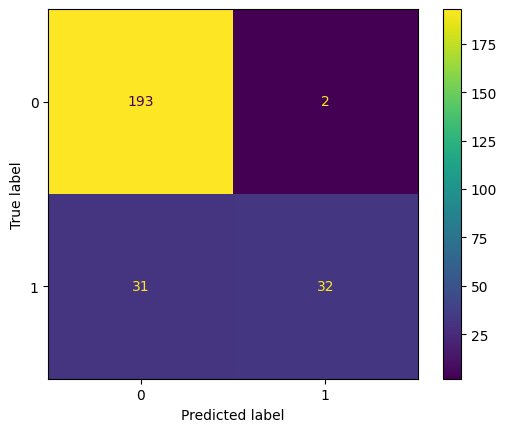

In [25]:
y_valid = dataset_orig_valid.labels
# y_pred = dataset_orig_valid_pred.labels

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline
cm_orig = confusion_matrix(y_valid, y_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_orig)
disp.plot()
plt.show()

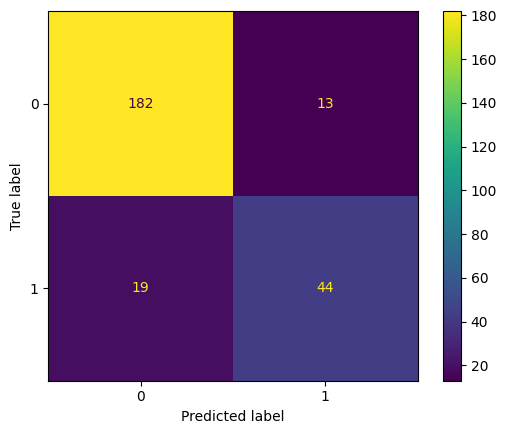

In [26]:
cm_transf = confusion_matrix(y_valid, y_test_transf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_transf)
disp.plot()
plt.show()

## 9. Identification of 'corrected' patients


In [27]:
# Extract PTIDs of validation set for result tracking
# # identify PTIDs of test cases
test_PTIDs = df_PTID[499:757] 
# print(test_PTIDs[:5])
# print (dataset_orig_valid.instance_names[:5])
test_PTIDs.reset_index(inplace=True)
test_PTIDs['index']
test_PTIDs = test_PTIDs.drop(['index'], axis=1) 
test_PTIDs

,PTID
0,116_S_4167
1,116_S_4175
2,116_S_4195
3,116_S_4199
4,116_S_4625
...,...
253,941_S_6803
254,941_S_6854
255,941_S_6962
256,941_S_7041


In [62]:
# Build comparison dataframe: true vs original vs debiased predictions
protected_attributes = dataset_transf_valid_pred.protected_attributes
protected_attributes.ravel()

df_ind = pd.DataFrame({
    "y_true": dataset_orig_valid.labels.ravel(),
    "pred_orig": dataset_orig_valid_pred.labels.ravel(),         
    "pred_transf": dataset_transf_valid_pred.labels.ravel(),                   
    "protected_attr": protected_attributes.ravel()
})
df_ind["Sex"] = df_ind["protected_attr"].map({0: "Male", 1: "Female"})
print(df_ind.shape)
df_ind.head()

(258, 5)


,y_true,pred_orig,pred_transf,protected_attr,Sex
0,0.0,0.0,0.0,1.0,Female
1,0.0,0.0,1.0,0.0,Male
2,1.0,1.0,1.0,0.0,Male
3,0.0,0.0,0.0,0.0,Male
4,1.0,1.0,1.0,0.0,Male


In [29]:
df_ind = pd.merge(test_PTIDs, df_ind, left_index=True, right_index=True)
print(df_ind.shape)
df_ind.tail()

(258, 6)


,PTID,y_true,pred_orig,pred_transf,protected_attr,Sex
253,941_S_6803,0.0,0.0,1.0,1.0,Female
254,941_S_6854,1.0,0.0,0.0,0.0,Male
255,941_S_6962,1.0,1.0,1.0,1.0,Female
256,941_S_7041,0.0,0.0,0.0,1.0,Female
257,941_S_7085,0.0,0.0,0.0,1.0,Female


In [30]:
# Identify cases misclassified by original but corrected by debiasing
improved_cases = df_ind[(df_ind['pred_orig'] != df_ind['y_true']) & (df_ind['pred_transf'] == df_ind['y_true'])]
# Print the result
print("Cases where the prediction was wrong before but correct after debiasing:")
print(len(improved_cases))
print(improved_cases[['PTID', 'y_true', 'pred_orig', 'pred_transf', 'Sex']])

Cases where the prediction was wrong before but correct after debiasing:
12
            PTID  y_true  pred_orig  pred_transf     Sex
24    123_S_6825     1.0        0.0          1.0  Female
34    126_S_6721     1.0        0.0          1.0    Male
63    128_S_4774     1.0        0.0          1.0    Male
105   135_S_4676     1.0        0.0          1.0    Male
110   135_S_4954     1.0        0.0          1.0    Male
127   137_S_0994     1.0        0.0          1.0  Female
139   137_S_4672     1.0        0.0          1.0    Male
178   168_S_6142     1.0        0.0          1.0  Female
195   168_S_6908     1.0        0.0          1.0  Female
220   341_S_6820     1.0        0.0          1.0    Male
233  941_S_10024     1.0        0.0          1.0    Male
236  941_S_10051     1.0        0.0          1.0  Female


## 10. Model interpretation with LIME


In [31]:
# LIME tabular explainer for interpretability
import lime
import lime.lime_tabular
from IPython.core.display import display, HTML
import warnings

/tmp/ipykernel_65999/3384812209.py:4: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [32]:
# Note: df.columns[1:150] is fragile — assumes consistent column ordering
X_train_XAI = pd.DataFrame(X_train)  
X_train_XAI.columns=df.columns[1:150]

X_test_XAI = pd.DataFrame(X_test) 
X_test_XAI.columns=df.columns[1:150]


# # Create a LIME explainer
class_names = [0, 1]
feature_names = list(X_train_XAI.columns)
explainer = lime.lime_tabular.LimeTabularExplainer(X_train_XAI.values, feature_names=feature_names, 
                                                        class_names=class_names, discretize_continuous=True)

In [33]:
# improved_cases.index
improved_cases.Sex

24     Female
34       Male
63       Male
105      Male
110      Male
127    Female
139      Male
178    Female
195    Female
220      Male
233      Male
236    Female
Name: Sex, dtype: object

In [34]:
# List of test instance indices
instance_indices = improved_cases.index #[4, 33, 46, 48, 112, 152, 153, 178, 191, 203, 220, 233, 237]


# Store results
all_lime_values = []

for idx in instance_indices:
    # Explain instance with LIME
    exp = explainer.explain_instance(X_test[idx], model.predict_proba, num_features=len(feature_names))
    
    # Convert to dictionary
    lime_dict = dict(exp.as_list())
    
    # Ensure all features are present
    for f in feature_names:
        if f not in lime_dict:
            lime_dict[f] = 0.0  # fill missing features with 0 contribution
    
    # Add instance index
    lime_dict['instance_index'] = idx
    
    # Append to list
    all_lime_values.append(lime_dict)

# Convert to DataFrame
lime_df = pd.DataFrame(all_lime_values)

# # Ensure instance_index is first column
# cols = ['instance_index'] + feature_names
# lime_df = lime_df[cols]

# Display


In [35]:
lime_df = pd.DataFrame(all_lime_values)
print(lime_df.shape)
lime_df.head()

(12, 472)


,PTETHCAT <= 0.20,DXPARK <= -0.12,CDJUDGE <= -0.21,CDGLOBAL <= -0.54,PTHOME > 0.46,LEFT_PHC_NS <= -0.13,RIGHT_PHC_NS <= -0.10,CDCARE <= -0.43,LEFT_MISC_VOL > 0.58,0.16 < WORLDSCORE_x <= 0.68,...,-0.01 < LEFT_DG_VOL <= 0.69,-0.51 < RIGHT_PHC_VOL <= 0.05,0.03 < RIGHT_DG_VOL <= 0.75,-0.71 < RIGHT_CA2_VOL <= -0.10,-0.21 < CDJUDGE <= 1.12,CDGLOBAL > 0.32,-0.73 < RIGHT_SULCUS_VOL <= -0.02,0.19 < LEFT_BA36_NS <= 0.49,RIGHT_ERC_NS > 0.83,-0.54 < FAQGAME <= 0.98
0,-0.360139,0.307628,-0.289032,-0.160753,-0.123439,0.106798,-0.102282,0.101910,-0.098091,-0.093465,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.329229,0.326156,-0.294145,-0.167720,-0.126787,NaN,NaN,0.112669,-0.130905,-0.110760,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.318640,0.296446,-0.296198,-0.159302,NaN,0.100181,-0.117584,0.102007,-0.133071,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.366024,0.296204,-0.298473,-0.145942,NaN,0.109701,-0.097160,0.109217,-0.109926,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.038109,0.277212,-0.295139,-0.165783,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
Sex = {'Male': 0,'Female': 1}
improved_cases.Sex = [Sex[item] for item in improved_cases.Sex]
improved_cases.Sex

/tmp/ipykernel_65999/2350920837.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  improved_cases.Sex = [Sex[item] for item in improved_cases.Sex]


24     1
34     0
63     0
105    0
110    0
127    1
139    0
178    1
195    1
220    0
233    0
236    1
Name: Sex, dtype: int64

In [37]:
df_lime_orig = lime_df.drop(['instance_index'], axis = 1)
df_lime_orig = df_lime_orig.dropna(axis=1)
df_lime_orig['gender'] = improved_cases['Sex'].values #[1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]  
print(df_lime_orig.shape)
df_lime_orig.head()

(12, 159)


,PTETHCAT <= 0.20,DXPARK <= -0.12,WORD2DL_x <= -0.86,PTNOTRT <= 0.31,GENOTYPE_2/4 <= -0.21,GENOTYPE_2/3 <= -0.25,DXNODEP <= 0.00,DXPDES <= 0.00,DXPCOG <= 0.00,DXPATYP <= 0.00,...,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS,gender
0,-0.360139,0.307628,0.075776,-0.051092,-0.027285,-0.018833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,-0.329229,0.326156,0.036189,-0.071837,-0.026476,-0.024747,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,-0.318640,0.296446,0.060459,-0.071296,-0.034099,-0.031761,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.366024,0.296204,0.059822,-0.028309,-0.013717,-0.023559,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,0.038109,0.277212,0.050816,-0.018949,-0.066792,-0.079628,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [38]:
df_lime_orig_males = df_lime_orig[df_lime_orig['gender'] == 0] 
df_lime_orig_females = df_lime_orig[df_lime_orig['gender'] == 1] 

In [40]:
# Prepare transformed data for LIME comparison
X_train_transf = pd.DataFrame(X_train_transf) 
X_train_transf.columns=df.columns[1:150]

# X_test_transf = pd.DataFrame(X_test_transf) 
# X_test_transf.columns=df.columns[1:150]

# Create a LIME explainer
class_names = [0, 1]
feature_names_transf = list(X_train_transf.columns)
explainer_lime_transf = lime.lime_tabular.LimeTabularExplainer(X_train_transf.values, feature_names=feature_names_transf, 
                                                        class_names=class_names, discretize_continuous=True)

In [41]:
# List of test instance indices
instance_indices = improved_cases.index #[4, 33, 46, 48, 112, 152, 153, 178, 191, 203, 220, 233, 237]

# Store results
all_lime_values_transf= []

for idx in instance_indices:
    # Explain instance with LIME
    exp_transf = explainer_lime_transf.explain_instance(X_test_transf[idx], model_transf.predict_proba, num_features=len(feature_names))
    
    # Convert to dictionary
    lime_dict_transf = dict(exp_transf.as_list())
    
    # Ensure all features are present
    for f in feature_names:
        if f not in lime_dict_transf:
            lime_dict_transf[f] = 0.0  # fill missing features with 0 contribution
    
    # Add instance index
    lime_dict_transf['instance_index'] = idx
    
    # Append to list
    all_lime_values_transf.append(lime_dict_transf)

# Convert to DataFrame
lime_df_transf = pd.DataFrame(all_lime_values_transf)

# # Ensure instance_index is first column
# cols = ['instance_index'] + feature_names
# lime_df_transf = lime_df_transf[cols]

# Display
# print(lime_df_transf.shape)
# lime_df_transf.head()

In [42]:
df_lime_transf = lime_df_transf.drop(['instance_index'], axis = 1)
df_lime_transf = df_lime_transf.dropna(axis=1)
df_lime_transf['gender'] = improved_cases['Sex'].values #[1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
df_lime_transf.shape

(12, 163)

In [43]:
df_lime_transf_males = df_lime_transf[df_lime_transf['gender'] == 0] 
df_lime_transf_females = df_lime_transf[df_lime_transf['gender'] == 1] 

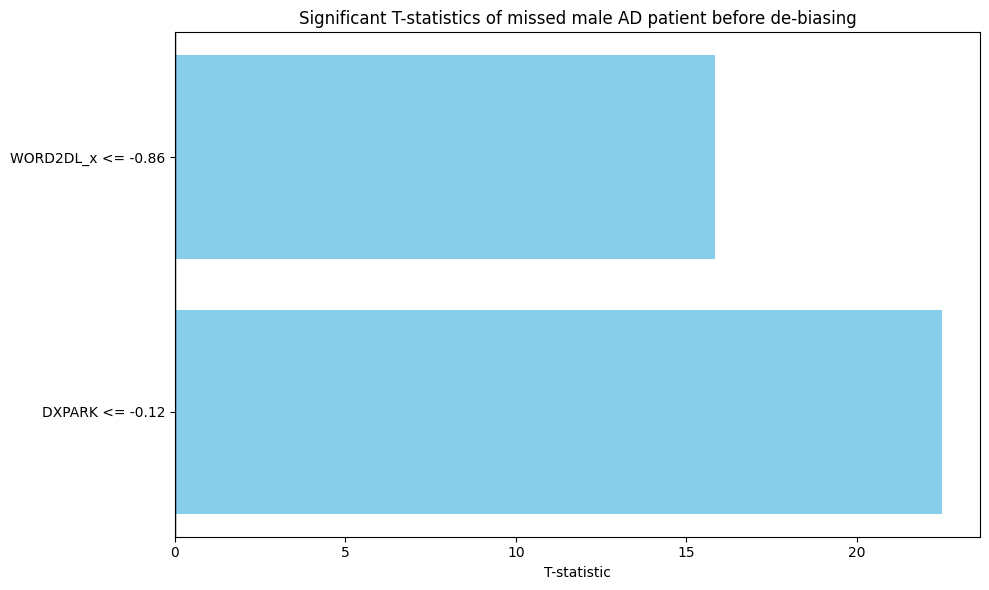

Significant Results (after Bonferroni correction, p-value < 0.00031):

Results for DXPARK <= -0.12:
Mean: 0.278
SD: 0.278
T-statistic: 22.493
P-value: 0.000
Results for WORD2DL_x <= -0.86:
Mean: 0.055
SD: 0.055
T-statistic: 15.838
P-value: 0.000


In [64]:
### ========================================================
### test for statistical significance of feature importance 
### using sex-specific one-sample t-tests on lime values  
### before and after de-biasing
### p-values are corrected for multiple comparisons 
### ========================================================

from scipy import stats

# Hypothesized population mean (mu = 0)
population_mean = 0

# Create an empty dictionary to store results
results_orig_males = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_orig_males.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_orig_males = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_orig_males.columns:
    sample_data_orig_males = df_lime_orig_males[column]
    # Descriptive statistics
    mean_orig_males = sample_data_orig_males.mean()
    sd_orig_males = sample_data_orig_males.std(ddof=1)

    # One-sample t-test
    t_statistic_orig_males, p_value_orig_males = stats.ttest_1samp(sample_data_orig_males, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_orig_males > 0:
        p_value_orig_males /= 2  # one-tailed test for 'greater than 0'
    
    results_orig_males[column] = {
        'Mean': mean_orig_males,
        'SD': sd_orig_males,
        'T-statistic': t_statistic_orig_males,
        'P-value': p_value_orig_males,
        'Reject Null Hypothesis': p_value_orig_males < alpha_bonferroni_orig_males
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_orig_males = {column: result for column, result in results_orig_males.items() if result['P-value'] < alpha_bonferroni_orig_males}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_orig_males:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_orig_males.keys()), [result['T-statistic'] for result in significant_results_orig_males.values()], color='skyblue')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of missed male AD patient before de-biasing')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_orig_males:.5f}):\n")
    for column, result in significant_results_orig_males.items():
        print(f"Results for {column}:")
        print(f"Mean: {result['Mean']:.3f}")
        print(f"SD: {result['Mean']:.3f}")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

/home/len_lin/Documents/ADNI/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


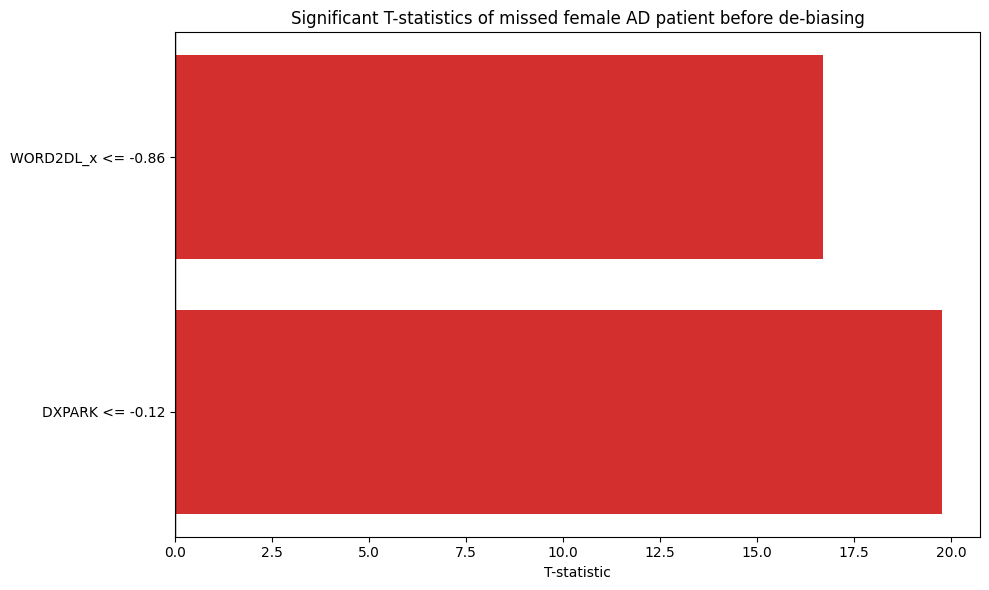

Significant Results (after Bonferroni correction, p-value < 0.00031):

Results for DXPARK <= -0.12:
Mean: 0.273
SD: 0.031
T-statistic: 19.754
P-value: 0.000
Results for WORD2DL_x <= -0.86:
Mean: 0.063
SD: 0.008
T-statistic: 16.704
P-value: 0.000
Results for gender:
Mean: 1.000
SD: 0.000
T-statistic: inf
P-value: 0.000


In [65]:
# # One-sample t-test of LIME feature contributions vs mean=0, by sex
# from scipy import stats

# # Hypothesized population mean (mu = 0)
# population_mean = 0

# Create an empty dictionary to store results
results_orig_females = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_orig_females.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_orig_females = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_orig_females.columns:
    sample_data_orig_females = df_lime_orig_females[column]
    
    # Descriptive statistics
    mean_orig_females = sample_data_orig_females.mean()
    sd_orig_females = sample_data_orig_females.std(ddof=1)

    # One-sample t-test
    t_statistic_orig_females, p_value_orig_females = stats.ttest_1samp(sample_data_orig_females, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_orig_females > 0:
        p_value_orig_females /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_orig_females[column] = {
        'Mean': mean_orig_females,
        'SD': sd_orig_females,        
        'T-statistic': t_statistic_orig_females,
        'P-value': p_value_orig_females,
        'Reject Null Hypothesis': p_value_orig_females < alpha_bonferroni_orig_females
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_orig_females = {column: result for column, result in results_orig_females.items() if result['P-value'] < alpha_bonferroni_orig_females}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_orig_females:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_orig_females.keys()), [result['T-statistic'] for result in significant_results_orig_females.values()], color='#D32F2F')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of missed female AD patient before de-biasing')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show();

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_orig_females:.5f}):\n")
    for column, result in significant_results_orig_females.items():
        print(f"Results for {column}:")
        print(f"Mean: {result['Mean']:.3f}")
        print(f"SD: {result['SD']:.3f}")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

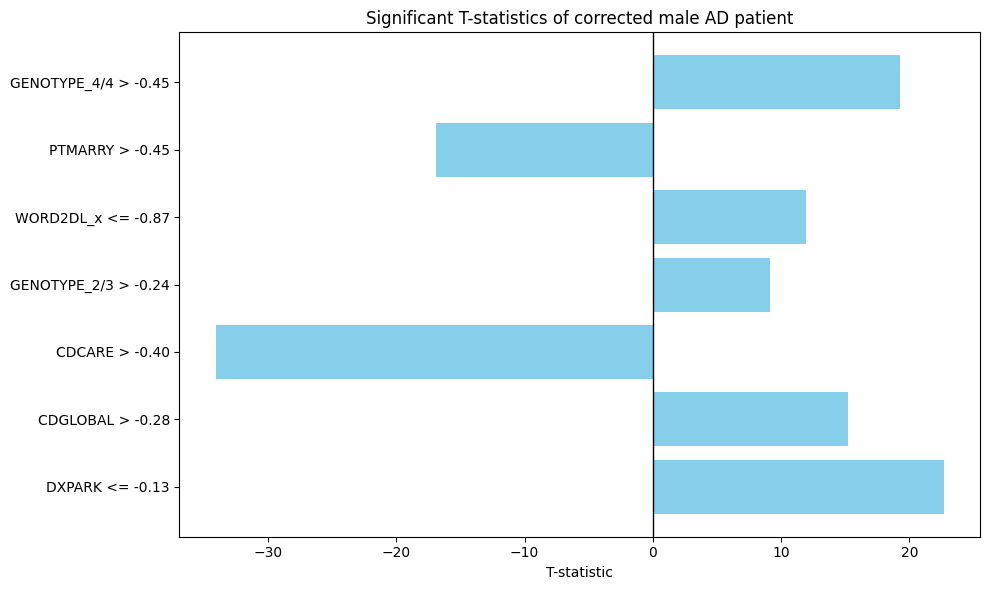

Significant Results (after Bonferroni correction, p-value < 0.00031):

Results for DXPARK <= -0.13:
Mean: 0.289
SD: 0.034
T-statistic: 22.671
P-value: 0.000
Results for CDGLOBAL > -0.28:
Mean: 0.108
SD: 0.019
T-statistic: 15.223
P-value: 0.000
Results for CDCARE > -0.40:
Mean: -0.118
SD: 0.009
T-statistic: -34.077
P-value: 0.000
Results for GENOTYPE_2/3 > -0.24:
Mean: 0.079
SD: 0.023
T-statistic: 9.154
P-value: 0.000
Results for WORD2DL_x <= -0.87:
Mean: 0.060
SD: 0.013
T-statistic: 11.962
P-value: 0.000
Results for PTMARRY > -0.45:
Mean: -0.061
SD: 0.009
T-statistic: -16.939
P-value: 0.000
Results for GENOTYPE_4/4 > -0.45:
Mean: 0.044
SD: 0.006
T-statistic: 19.238
P-value: 0.000


In [66]:
# One-sample t-test of LIME feature contributions vs mean=0, by sex
# Hypothesized population mean (mu = 0)
# population_mean = 0

# Create an empty dictionary to store results
results_transf_males = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_transf_males.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_transf_males = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_transf_males.columns:
    sample_data_transf_males = df_lime_transf_males[column]

    # Descriptive statistics
    mean_transf_males = sample_data_transf_males.mean()
    sd_transf_males = sample_data_transf_males.std(ddof=1)

    # One-sample t-test    
    t_statistic_transf_males, p_value_transf_males = stats.ttest_1samp(sample_data_transf_males, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_transf_males > 0:
        p_value_transf_males /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_transf_males[column] = {
        'Mean': mean_transf_males,
        'SD': sd_transf_males,    
        'T-statistic': t_statistic_transf_males,
        'P-value': p_value_transf_males,
        'Reject Null Hypothesis': p_value_transf_males < alpha_bonferroni_transf_males
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_transf_males = {column: result for column, result in results_transf_males.items() if result['P-value'] < alpha_bonferroni_transf_males}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_transf_males:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_transf_males.keys()), [result['T-statistic'] for result in significant_results_transf_males.values()], color='skyblue')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of corrected male AD patient')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_transf_males:.5f}):\n")
    for column, result in significant_results_transf_males.items():
        print(f"Results for {column}:")
        print(f"Mean: {result['Mean']:.3f}")
        print(f"SD: {result['SD']:.3f}")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

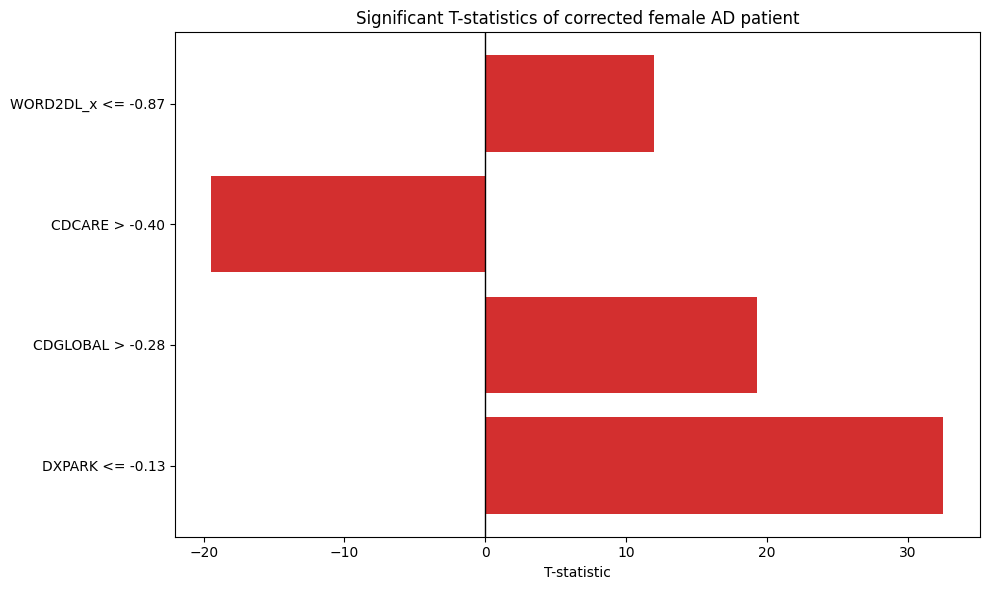

Significant Results (after Bonferroni correction, p-value < 0.00031):

Results for DXPARK <= -0.13:
Mean: 0.259
SD: 0.018
T-statistic: 32.546
P-value: 0.000
Results for CDGLOBAL > -0.28:
Mean: 0.121
SD: 0.014
T-statistic: 19.295
P-value: 0.000
Results for CDCARE > -0.40:
Mean: -0.114
SD: 0.013
T-statistic: -19.451
P-value: 0.000
Results for WORD2DL_x <= -0.87:
Mean: 0.058
SD: 0.011
T-statistic: 11.954
P-value: 0.000
Results for gender:
Mean: 1.000
SD: 0.000
T-statistic: inf
P-value: 0.000


In [67]:
# One-sample t-test of LIME feature contributions vs mean=0, by sex
# # Hypothesized population mean (mu = 0)
# population_mean = 0

# Create an empty dictionary to store results
results_transf_females = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_transf_females.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_transf_females = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_transf_females.columns:
    sample_data_transf_females = df_lime_transf_females[column]

    # Descriptive statistics
    mean_transf_females = sample_data_transf_females.mean()
    sd_transf_females = sample_data_transf_females.std(ddof=1)

    # One-sample t-test    
    t_statistic_transf_females, p_value_transf_females = stats.ttest_1samp(sample_data_transf_females, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_transf_females > 0:
        p_value_transf_females /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_transf_females[column] = {
        'Mean': mean_transf_females,
        'SD': sd_transf_females,    
        'T-statistic': t_statistic_transf_females,
        'P-value': p_value_transf_females,
        'Reject Null Hypothesis': p_value_transf_females < alpha_bonferroni_transf_females
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_transf_females = {column: result for column, result in results_transf_females.items() if result['P-value'] < alpha_bonferroni_transf_females}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_transf_females:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_transf_females.keys()), [result['T-statistic'] for result in significant_results_transf_females.values()], color='#D32F2F')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of corrected female AD patient')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_transf_females:.5f}):\n")
    for column, result in significant_results_transf_females.items():
        print(f"Results for {column}:")
        print(f"Mean: {result['Mean']:.3f}")
        print(f"SD: {result['SD']:.3f}")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

In [68]:
print(len(df_lime_orig_females.columns))
print(len(df_lime_orig_males.columns))
print(len(df_lime_transf_females.columns))
print(len(df_lime_transf_males.columns))

159
159
163
163


---
## Appendix: additional mitigation algorithms


These methods were explored but not included in the main analysis. Code is preserved for reference.


### Adversarial Debiasing (in-processing, TF-based)


In [48]:
#warnings.filterwarnings("ignore")
#tf.compat.v1.disable_eager_execution()  # Ensure TF2 compatibility
#sess = tf.compat.v1.Session()
#plain_model = aif360.algorithms.inprocessing.AdversarialDebiasing(
#    privileged_groups=privileged_groups,
#    unprivileged_groups=unprivileged_groups,
#    scope_name='original_model',
#    debias=False,
#    sess=sess,
#    num_epochs=50,
#    batch_size=128,
#    classifier_num_hidden_units=128
#)


#plain_model.fit(dataset_orig_train)
#dataset_nodebiasing_train = plain_model.predict(dataset_orig_train) 
#dataset_nodebiasing_valid = plain_model.predict(dataset_orig_valid) 

In [49]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr):
#  
#    fav_inds = dataset_nodebiasing_valid.scores > class_thresh
#    dataset_nodebiasing_valid.labels[fav_inds] = dataset_nodebiasing_valid.favorable_label
#    dataset_nodebiasing_valid.labels[~fav_inds] = dataset_nodebiasing_valid.unfavorable_label
#    
#    classified_metric_valid = ClassificationMetric(dataset_orig_valid,
#                                             dataset_nodebiasing_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
#                       +classified_metric_valid.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh = class_thresh_arr[best_ind]

#display(Markdown("#### Predictions from testing data before Adversarial Debiasing"))
#bal_acc_arr_orig = []
#disp_imp_arr_orig = []
## avg_odds_diff_arr_orig = []
#mean_diff_arr_orig = []

#print("Classification threshold used = %.4f" % best_class_thresh)
#for thresh in tqdm(class_thresh_arr):
#    
#    if thresh == best_class_thresh:
#        disp = True
#    else:
#        disp = False
   
#    fav_inds = dataset_nodebiasing_valid.scores > thresh
#    dataset_nodebiasing_valid.labels[fav_inds] = dataset_nodebiasing_valid.favorable_label
#    dataset_nodebiasing_valid.labels[~fav_inds] = dataset_nodebiasing_valid.unfavorable_label
    
#    metric_valid_bef = compute_metrics(dataset_orig_valid, dataset_nodebiasing_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_orig.append(metric_valid_bef["Balanced accuracy"])
#    # avg_odds_diff_arr_orig.append(metric_valid_bef["Average odds difference"])
#    disp_imp_arr_orig.append(metric_valid_bef["Disparate impact"])
#    mean_diff_arr_orig.append(metric_valid_bef["Mean Difference"])

In [50]:
#warnings.filterwarnings("ignore")
## Learn parameters with debias set to True
#debiased_model = AdversarialDebiasing(privileged_groups = privileged_groups,
#                          unprivileged_groups = unprivileged_groups,
#                          scope_name='debiased_classifier',
#                          debias=True,
#                          sess=sess)
#debiased_model.fit(dataset_orig_train)
#dataset_debiasing_train = debiased_model.predict(dataset_orig_train)
#dataset_debiasing_valid = debiased_model.predict(dataset_orig_valid)

In [51]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_debiased = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_debiased):
    
#    fav_inds = dataset_debiasing_valid.scores > class_thresh
#    dataset_debiasing_valid.labels[fav_inds] = dataset_debiasing_valid.favorable_label
#    dataset_debiasing_valid.labels[~fav_inds] = dataset_debiasing_valid.unfavorable_label
    
#    classified_metric_valid = ClassificationMetric(dataset_orig_valid,
#                                             dataset_debiasing_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
#                       +classified_metric_valid.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_debiased = class_thresh_arr_debiased[best_ind]

#display(Markdown("#### Predictions from testing data after Adversarial Debiasing"))

#bal_acc_arr_debiased = []
#disp_imp_arr_debiased = []
#avg_odds_diff_arr_debiased = []
#mean_diff_arr_debiased = []

#print("Classification threshold used = %.4f" % best_class_thresh_debiased)
#for thresh in tqdm(class_thresh_arr_debiased):
    
#    if thresh == best_class_thresh_debiased:
#        disp = True
#    else:
#        disp = False
    
#    fav_inds = dataset_debiasing_valid.scores > thresh
#    dataset_debiasing_valid.labels[fav_inds] = dataset_debiasing_valid.favorable_label
#    dataset_debiasing_valid.labels[~fav_inds] = dataset_debiasing_valid.unfavorable_label
    
#    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_debiasing_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_debiased.append(metric_valid_aft["Balanced accuracy"])
#    # avg_odds_diff_arr_debiased.append(metric_valid_aft["Average odds difference"])
#    disp_imp_arr_debiased.append(metric_valid_aft["Disparate impact"])
#    mean_diff_arr_debiased.append(metric_valid_aft["Mean Difference"])

### Prejudice Remover (in-processing)


In [52]:
#warnings.filterwarnings("ignore")
## # Learn parameters with debias set to True
#debiased_model_PR = aif360.algorithms.inprocessing.PrejudiceRemover()
#debiased_model_PR.fit(dataset_orig_train)

#dataset_debiasing_PR_train = debiased_model_PR.predict(dataset_orig_train)
#dataset_debiasing_PR_valid = debiased_model_PR.predict(dataset_orig_valid)

In [53]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_PR = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_PR):
    
#    fav_inds = dataset_debiasing_PR_valid.scores > class_thresh
#    dataset_debiasing_PR_valid.labels[fav_inds] = dataset_debiasing_PR_valid.favorable_label
#    dataset_debiasing_PR_valid.labels[~fav_inds] = dataset_debiasing_PR_valid.unfavorable_label
    
#    classified_metric_valid_PR = ClassificationMetric(dataset_orig_valid,
#                                             dataset_debiasing_PR_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid_PR.true_positive_rate()\
#                       +classified_metric_valid_PR.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_PR = class_thresh_arr_PR[best_ind]
#display(Markdown("#### Predictions of testing data after Prejudice Remover"))

#bal_acc_arr_PR = []
#disp_imp_arr_PR = []
## avg_odds_diff_arr_PR = []
#mean_diff_arr_PR = []

#print("Classification threshold used = %.4f" % best_class_thresh_PR)
#for thresh in tqdm(class_thresh_arr_PR):
    
#    if thresh == best_class_thresh_PR:
#        disp = True
#    else:
#        disp = False
  
#    fav_inds = dataset_debiasing_PR_valid.scores > thresh
#    dataset_debiasing_PR_valid.labels[fav_inds] = dataset_debiasing_PR_valid.favorable_label
#    dataset_debiasing_PR_valid.labels[~fav_inds] = dataset_debiasing_PR_valid.unfavorable_label
    
#    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_debiasing_PR_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_PR.append(metric_valid_aft["Balanced accuracy"])
#    # avg_odds_diff_arr_PR.append(metric_test_aft["Average odds difference"])
#    disp_imp_arr_PR.append(metric_valid_aft["Disparate impact"])
#    mean_diff_arr_PR.append(metric_valid_aft["Mean Difference"])

### Calibrated Equal Odds Postprocessing 


In [54]:
# # Calibrated Equal Odds Post-processing

# # cost constraint of fnr will optimize generalized false negative rates, that of
# # fpr will optimize generalized false positive rates, and weighted will optimize
# # a weighted combination of both
#cost_constraint = "fnr" # "fnr", "fpr", "weighted"
# #random seed for calibrated equal odds prediction
#randseed = 12345679 

#cm_pred_valid = ClassificationMetric(dataset_orig_valid, dataset_orig_valid_pred,
#                             unprivileged_groups=unprivileged_groups,
#                             privileged_groups=privileged_groups)
#display(Markdown("#### Original-Predicted validation dataset"))
#print("Difference in GFPR between unprivileged and privileged groups")
#print(cm_pred_valid.difference(cm_pred_valid.generalized_false_positive_rate))
#print("Difference in GFNR between unprivileged and privileged groups")
#print(cm_pred_valid.difference(cm_pred_valid.generalized_false_negative_rate))

In [55]:
# # # Learn parameters to equalize odds and apply to create a new dataset
#cpp = CalibratedEqOddsPostprocessing(privileged_groups = privileged_groups,
#                                     unprivileged_groups = unprivileged_groups,
#                                     cost_constraint=cost_constraint,
#                                     seed=randseed)
#cpp = cpp.fit(dataset_orig_valid, dataset_orig_valid_pred)
#dataset_transf_valid_pred = cpp.predict(dataset_orig_valid_pred)

In [56]:
#cm_transf_valid = ClassificationMetric(dataset_orig_valid, dataset_transf_valid_pred,
#                             unprivileged_groups=unprivileged_groups,
#                             privileged_groups=privileged_groups)
#display(Markdown("#### Transformed validation dataset"))
#print("Difference in GFPR between unprivileged and privileged groups")
#print(cm_transf_valid.difference(cm_transf_valid.generalized_false_positive_rate))
#print("Difference in GFNR between unprivileged and privileged groups")
#print(cm_transf_valid.difference(cm_transf_valid.generalized_false_negative_rate))

In [57]:
#all_thresh = np.linspace(0.01, 0.99, 25)
#display(Markdown("#### Classification thresholds used for validation and parameter selection"))
#aft_avg_odds_diff_test = []
#bef_bal_acc_valid = []
#aft_bal_acc_valid = []

#for thresh in tqdm(all_thresh):
 
#    dataset_orig_valid_pred_thresh = dataset_orig_valid_pred.copy(deepcopy=True)
#    dataset_cpp_transf_valid_pred_thresh = dataset_transf_valid_pred.copy(deepcopy=True)
    
#    y_temp = np.zeros_like(dataset_orig_valid_pred_thresh.labels)
#    y_temp[dataset_orig_valid_pred_thresh.scores >= thresh] = dataset_orig_valid_pred_thresh.favorable_label
#    y_temp[~(dataset_orig_valid_pred_thresh.scores >= thresh)] = dataset_orig_valid_pred_thresh.unfavorable_label
#    dataset_orig_valid_pred_thresh.labels = y_temp
    

#    classified_metric_orig_valid = ClassificationMetric(dataset_orig_valid,
#                                                 dataset_orig_valid_pred_thresh,
#                                                 unprivileged_groups=unprivileged_groups,
 #                                                privileged_groups=privileged_groups)
    # bef_avg_odds_diff_test.append(classified_metric_orig_test.equal_opportunity_difference())
#    bef_bal_acc_valid.append(0.5*(classified_metric_orig_valid.true_positive_rate()+
#                              classified_metric_orig_valid.true_negative_rate()))

    
#     # Metrics for transf test data
#    classified_metric_transf_valid = ClassificationMetric(dataset_orig_valid,
#                                                 dataset_cpp_transf_valid_pred_thresh,
#                                                 unprivileged_groups=unprivileged_groups,
#                                                 privileged_groups=privileged_groups)
#    # aft_avg_odds_diff_test.append(classified_metric_transf_valid.equal_opportunity_difference())
#    aft_bal_acc_valid.append(0.5*(classified_metric_transf_valid.true_positive_rate()+
#                                   classified_metric_transf_valid.true_negative_rate()))

In [58]:
# # # Predictions from the  cEOP-transformed test set at the optimal classification threshold
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_transf_cpp = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_transf_cpp):
    
#    fav_inds = dataset_transf_valid_pred.scores > class_thresh
#    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
  
#    classified_metric_valid_transf_cpp = ClassificationMetric(dataset_orig_valid,
 #                                            dataset_transf_valid_pred, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
#    
#    ba_arr[idx] = 0.5*(classified_metric_valid_transf_cpp.true_positive_rate()\
#                       +classified_metric_valid_transf_cpp.true_negative_rate())
#best_ind_cpp = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_cpp = class_thresh_arr_transf_cpp[best_ind_cpp]

#display(Markdown("#### Predictions from  cEOP-transformed testing data"))
#bal_acc_arr_transf_cpp = []
#disp_imp_arr_transf_cpp = []
## avg_odds_diff_arr_transf_cpp = []
#mean_diff_arr_transf_cpp = []

#print("Classification threshold used = %.4f" % best_class_thresh_cpp)
#for thresh in tqdm(class_thresh_arr_transf_cpp):
    
#    if thresh == best_class_thresh_cpp:
#        disp = True
#    else:
#        disp = False
   
#    fav_inds = dataset_transf_valid_pred.scores > thresh
#    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
#    metric_valid_aft_cpp = compute_metrics(dataset_orig_valid, dataset_transf_valid_pred, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_transf_cpp.append(metric_valid_aft_cpp["Balanced accuracy"])
    # avg_odds_diff_arr_transf_cpp.append(metric_test_aft_cpp["Average odds difference"])
#    disp_imp_arr_transf_cpp.append(metric_valid_aft_cpp["Disparate impact"])
#    mean_diff_arr_transf_cpp.append(metric_valid_aft_cpp["Mean Difference"])

### XGBoost classifier on original data (alternative to SVC)


In [59]:
# # XGBoost

# # for grid search
# xgb = XGBClassifier()
# # param_grid = {
# #    'n_estimators': [100, 200, 300],
# #    'learning_rate': [0.01, 0.1, 0.2],
# #    'max_depth': [3, 5, 7],
# #    'min_child_weight': [1, 3, 5],
# #    'subsample': [0.6, 0.8, 1.0],
# #    'colsample_bytree': [0.6, 0.8, 1.0]
# # }
# # grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
# # grid_search.fit(X_train, y_train)
# # params=grid_search.best_params_
# # print(grid_search.best_params_)


# model = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, 
#                           n_estimators=100, subsample=0.6, reg_alpha=0.1, reg_lambda=1.0, random_state=42)
# model.fit(X_train, y_train)

### XGBoost on debiased data 


In [60]:
# # # # # transfer XGBoost model
# model_transf = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, 
#                           n_estimators=100, subsample=0.6, reg_alpha=0.1, reg_lambda=1.0, random_state=42)
# model_transf.fit(X_train_transf, y_train_transf)

# pos_ind = np.where(model_transf.classes_ == dataset_transf_train.favorable_label)[0][0]
# y_train_transf_pred = model_transf.predict(X_train_transf)